# Bottleneck & Corridor Audit

## Objective
Identify which hubs are structural bottlenecks using graph centrality metrics.

## Metrics Used
- **Betweenness Centrality:** How often a hub sits on shortest paths between other hubs
- **In/Out Degree:** How many routes connect to each hub  
- **Clustering Coefficient:** How interconnected a hub's neighbors are
- **Combined Bottleneck Score:** Weighted combination of all above metrics

## Key Finding
IND000000ACB sits on 22.9% of all shortest delivery paths — 
the single most critical hub in the entire network.

## Step 1: Load Graph & Compute Betweenness Centrality
Betweenness centrality measures how critical each hub is for routing.
A hub with high betweenness is a chokepoint — if it fails, many routes break.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# Load saved graph and data
G = nx.read_gexf('../data/logistics_graph.gexf')
corridor_stats = pd.read_csv('../data/corridor_stats.csv')
df = pd.read_csv('../data/delivery_data.csv')
df = df[df['segment_factor'] > 0].dropna(subset=['source_name','destination_name'])

print("Graph loaded!")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Compute betweenness centrality
# This measures: how often does a hub sit on the shortest path between two other hubs?
# High score = critical hub, if it fails the whole network suffers
print("\nComputing betweenness centrality (may take 30-60 seconds)...")
betweenness = nx.betweenness_centrality(G, weight='weight')
print("Done!")

top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Hubs by Betweenness Centrality:")
for hub, score in top_betweenness:
    print(f"  {hub}: {score:.4f}")

Graph loaded!
Nodes: 1641, Edges: 2741

Computing betweenness centrality (may take 30-60 seconds)...
Done!

Top 10 Hubs by Betweenness Centrality:
  IND000000ACB: 0.2294
  IND562132AAA: 0.1526
  IND712311AAA: 0.0814
  IND501359AAE: 0.0768
  IND421302AAG: 0.0543
  IND160002AAC: 0.0535
  IND110037AAM: 0.0512
  IND131028AAB: 0.0469
  IND411033AAA: 0.0458
  IND781018AAB: 0.0444


## Step 2: Combined Bottleneck Score
Normalize each metric and combine into a single score.
Weights: betweenness (40%), in-degree (20%), out-degree (20%), avg delay (20%).

In [2]:
# Get in and out degree for each node
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

# Get average delay for each hub (as source)
hub_delay = df.groupby('source_center')['segment_factor'].median().to_dict()

# Combine into a single dataframe
hub_df = pd.DataFrame({
    'hub': list(betweenness.keys()),
    'betweenness': list(betweenness.values()),
    'in_degree': [in_deg.get(h, 0) for h in betweenness.keys()],
    'out_degree': [out_deg.get(h, 0) for h in betweenness.keys()],
    'avg_delay': [hub_delay.get(h, 0) for h in betweenness.keys()]
})

# Normalize each metric 0-1 and compute combined bottleneck score
for col in ['betweenness', 'in_degree', 'out_degree', 'avg_delay']:
    hub_df[col+'_norm'] = (hub_df[col] - hub_df[col].min()) / (hub_df[col].max() - hub_df[col].min())

# Bottleneck score = weighted combination
hub_df['bottleneck_score'] = (
    0.4 * hub_df['betweenness_norm'] +
    0.2 * hub_df['in_degree_norm'] +
    0.2 * hub_df['out_degree_norm'] +
    0.2 * hub_df['avg_delay_norm']
)

hub_df = hub_df.sort_values('bottleneck_score', ascending=False).reset_index(drop=True)

print("Top 15 Bottleneck Hubs:")
print(hub_df[['hub','betweenness','in_degree','out_degree','avg_delay','bottleneck_score']].head(15).to_string())

Top 15 Bottleneck Hubs:
             hub  betweenness  in_degree  out_degree  avg_delay  bottleneck_score
0   IND000000ACB     0.229355         45          47   1.571429          0.808980
1   IND562132AAA     0.152608         36          35   1.500000          0.583659
2   IND501359AAE     0.076800         30          27   1.700000          0.391883
3   IND160002AAC     0.053546         32          29   1.680000          0.368612
4   IND421302AAG     0.054282         29          29   1.777778          0.357121
5   IND712311AAA     0.081370         24          22   1.812500          0.352552
6   IND110037AAM     0.051242         20          22   1.653846          0.281323
7   IND411033AAA     0.045795         23          20   1.562500          0.276125
8   IND131028AAB     0.046898         20          19   1.500000          0.260103
9   IND600056AAB     0.041556         18          18   1.625000          0.238356
10  IND781018AAB     0.044414         17          15   1.838919          0

## Step 3: Visualize Bottleneck Hubs
Left chart: overall bottleneck ranking.
Right chart: betweenness vs delay — bubble size shows number of connections.
Hubs in top-right corner are both structurally critical AND badly delayed.

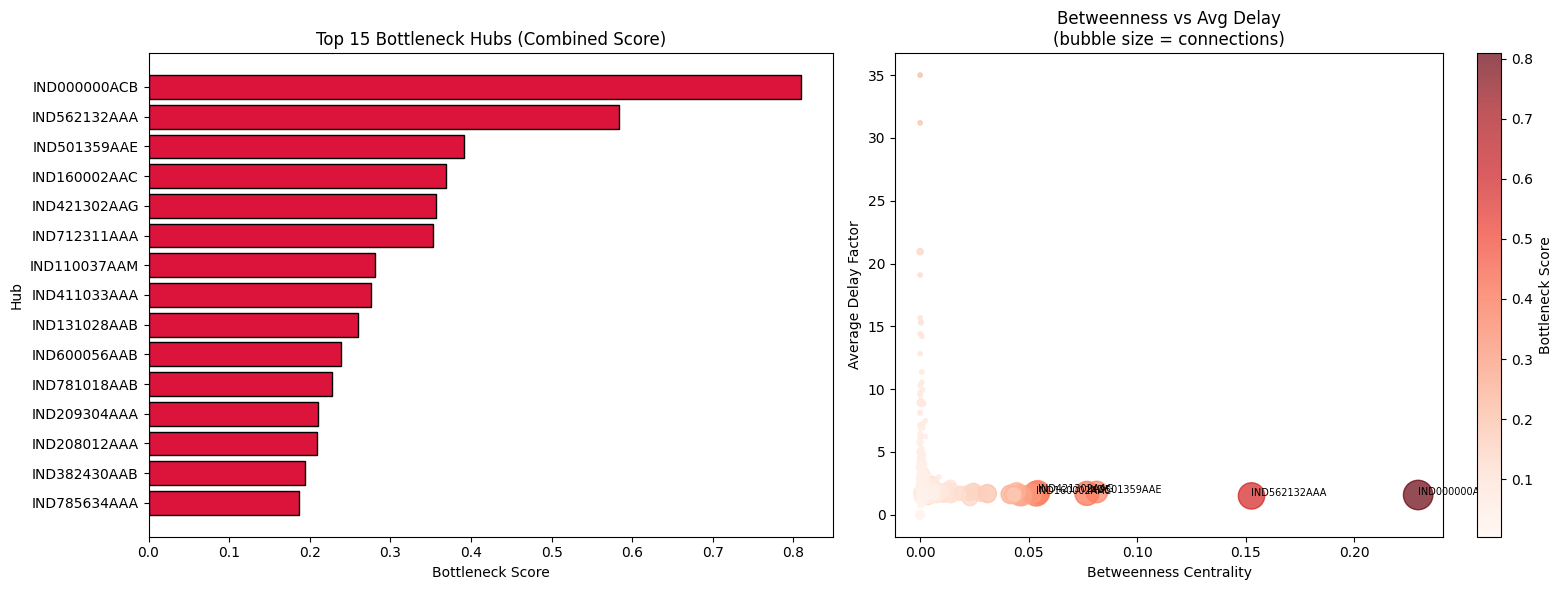

Plot saved!


In [3]:
top15 = hub_df.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bottleneck score bar chart
axes[0].barh(top15['hub'][::-1], top15['bottleneck_score'][::-1], color='crimson', edgecolor='black')
axes[0].set_title('Top 15 Bottleneck Hubs (Combined Score)')
axes[0].set_xlabel('Bottleneck Score')
axes[0].set_ylabel('Hub')

# Betweenness vs Avg Delay scatter
scatter = axes[1].scatter(
    hub_df['betweenness'], 
    hub_df['avg_delay'],
    c=hub_df['bottleneck_score'],
    cmap='Reds',
    alpha=0.7,
    s=hub_df['in_degree']*10
)
plt.colorbar(scatter, ax=axes[1], label='Bottleneck Score')

# Label top 5
for _, row in hub_df.head(5).iterrows():
    axes[1].annotate(row['hub'], 
                    (row['betweenness'], row['avg_delay']),
                    fontsize=7, ha='left')

axes[1].set_title('Betweenness vs Avg Delay\n(bubble size = connections)')
axes[1].set_xlabel('Betweenness Centrality')
axes[1].set_ylabel('Average Delay Factor')

plt.tight_layout()
plt.savefig('../outputs/bottleneck_hubs.png')
plt.show()
print("Plot saved!")

## Step 4: Tier Classification
Tier 1 (score > 0.3): Critical hubs requiring immediate attention.
Tier 2 (score 0.2–0.3): Important hubs requiring monitoring.

In [4]:
# Save hub rankings for use in later notebooks
hub_df.to_csv('../data/hub_bottleneck_scores.csv', index=False)

# Summary print for the memo
print("=== BOTTLENECK AUDIT SUMMARY ===")
print(f"\nTotal hubs in network: {G.number_of_nodes()}")
print(f"Total corridors: {G.number_of_edges()}")
print(f"\nCritical Tier 1 Hubs (bottleneck score > 0.3):")
tier1 = hub_df[hub_df['bottleneck_score'] > 0.3]
for _, row in tier1.iterrows():
    print(f"  {row['hub']} — score: {row['bottleneck_score']:.3f}, delay: {row['avg_delay']:.2f}x, connections: {int(row['in_degree'])+int(row['out_degree'])}")

print(f"\nCritical Tier 2 Hubs (bottleneck score 0.2–0.3):")
tier2 = hub_df[(hub_df['bottleneck_score'] >= 0.2) & (hub_df['bottleneck_score'] <= 0.3)]
for _, row in tier2.iterrows():
    print(f"  {row['hub']} — score: {row['bottleneck_score']:.3f}, delay: {row['avg_delay']:.2f}x, connections: {int(row['in_degree'])+int(row['out_degree'])}")

=== BOTTLENECK AUDIT SUMMARY ===

Total hubs in network: 1641
Total corridors: 2741

Critical Tier 1 Hubs (bottleneck score > 0.3):
  IND000000ACB — score: 0.809, delay: 1.57x, connections: 92
  IND562132AAA — score: 0.584, delay: 1.50x, connections: 71
  IND501359AAE — score: 0.392, delay: 1.70x, connections: 57
  IND160002AAC — score: 0.369, delay: 1.68x, connections: 61
  IND421302AAG — score: 0.357, delay: 1.78x, connections: 58
  IND712311AAA — score: 0.353, delay: 1.81x, connections: 46

Critical Tier 2 Hubs (bottleneck score 0.2–0.3):
  IND110037AAM — score: 0.281, delay: 1.65x, connections: 42
  IND411033AAA — score: 0.276, delay: 1.56x, connections: 43
  IND131028AAB — score: 0.260, delay: 1.50x, connections: 39
  IND600056AAB — score: 0.238, delay: 1.62x, connections: 36
  IND781018AAB — score: 0.227, delay: 1.84x, connections: 32
  IND209304AAA — score: 0.210, delay: 1.61x, connections: 29
  IND208012AAA — score: 0.209, delay: 35.00x, connections: 2


## Step 5: Clustering Coefficient
Low clustering + high betweenness = bridge hub — most dangerous type.
No alternative paths exist if this hub fails.

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Reload graph and hub scores
G = nx.read_gexf('../data/logistics_graph.gexf')
hub_df = pd.read_csv('../data/hub_bottleneck_scores.csv')

print("Loaded! Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

# Clustering Coefficient
# Measures how interconnected a hub's neighbors are
# Low value = hub is a BRIDGE between disconnected parts (critical bottleneck)
# High value = hub's neighbors are well connected to each other (resilient zone)

G_undirected = G.to_undirected()
clustering = nx.clustering(G_undirected)

# Add to hub dataframe
hub_df['clustering_coeff'] = hub_df['hub'].map(clustering).fillna(0)

print("\n=== COMPLETE BOTTLENECK PROFILE (with Clustering Coefficient) ===")
print(hub_df[['hub','betweenness','in_degree','out_degree',
              'avg_delay','clustering_coeff','bottleneck_score']].head(15).to_string())

print("\n--- Interpretation ---")
print("Low clustering + high betweenness = structural bottleneck (bridge hub)")
print("High clustering + high betweenness = busy but resilient hub")

low_cluster = hub_df[hub_df['clustering_coeff'] < 0.05].head(5)
print(f"\nMost vulnerable bridge hubs (clustering < 0.05):")
print(low_cluster[['hub','clustering_coeff','betweenness','bottleneck_score']].to_string())

Loaded! Nodes: 1641 Edges: 2741

=== COMPLETE BOTTLENECK PROFILE (with Clustering Coefficient) ===
             hub  betweenness  in_degree  out_degree  avg_delay  clustering_coeff  bottleneck_score
0   IND000000ACB     0.229355         45          47   1.571429          0.037989          0.808980
1   IND562132AAA     0.152608         36          35   1.500000          0.053571          0.583659
2   IND501359AAE     0.076800         30          27   1.700000          0.042683          0.391883
3   IND160002AAC     0.053546         32          29   1.680000          0.034330          0.368612
4   IND421302AAG     0.054282         29          29   1.777778          0.061562          0.357121
5   IND712311AAA     0.081370         24          22   1.812500          0.039216          0.352552
6   IND110037AAM     0.051242         20          22   1.653846          0.068966          0.281323
7   IND411033AAA     0.045795         23          20   1.562500          0.061576          0.276125
8

In [3]:
# Save updated hub scores with clustering coefficient
hub_df.to_csv('../data/hub_bottleneck_scores.csv', index=False)
print("Updated hub scores saved with clustering coefficient!")

Updated hub scores saved with clustering coefficient!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

G = nx.read_gexf('../data/logistics_graph.gexf')
hub_df = pd.read_csv('../data/hub_bottleneck_scores.csv')
hub_score_dict = dict(zip(hub_df['hub'], hub_df['bottleneck_score']))
print("Loaded!")

Loaded!


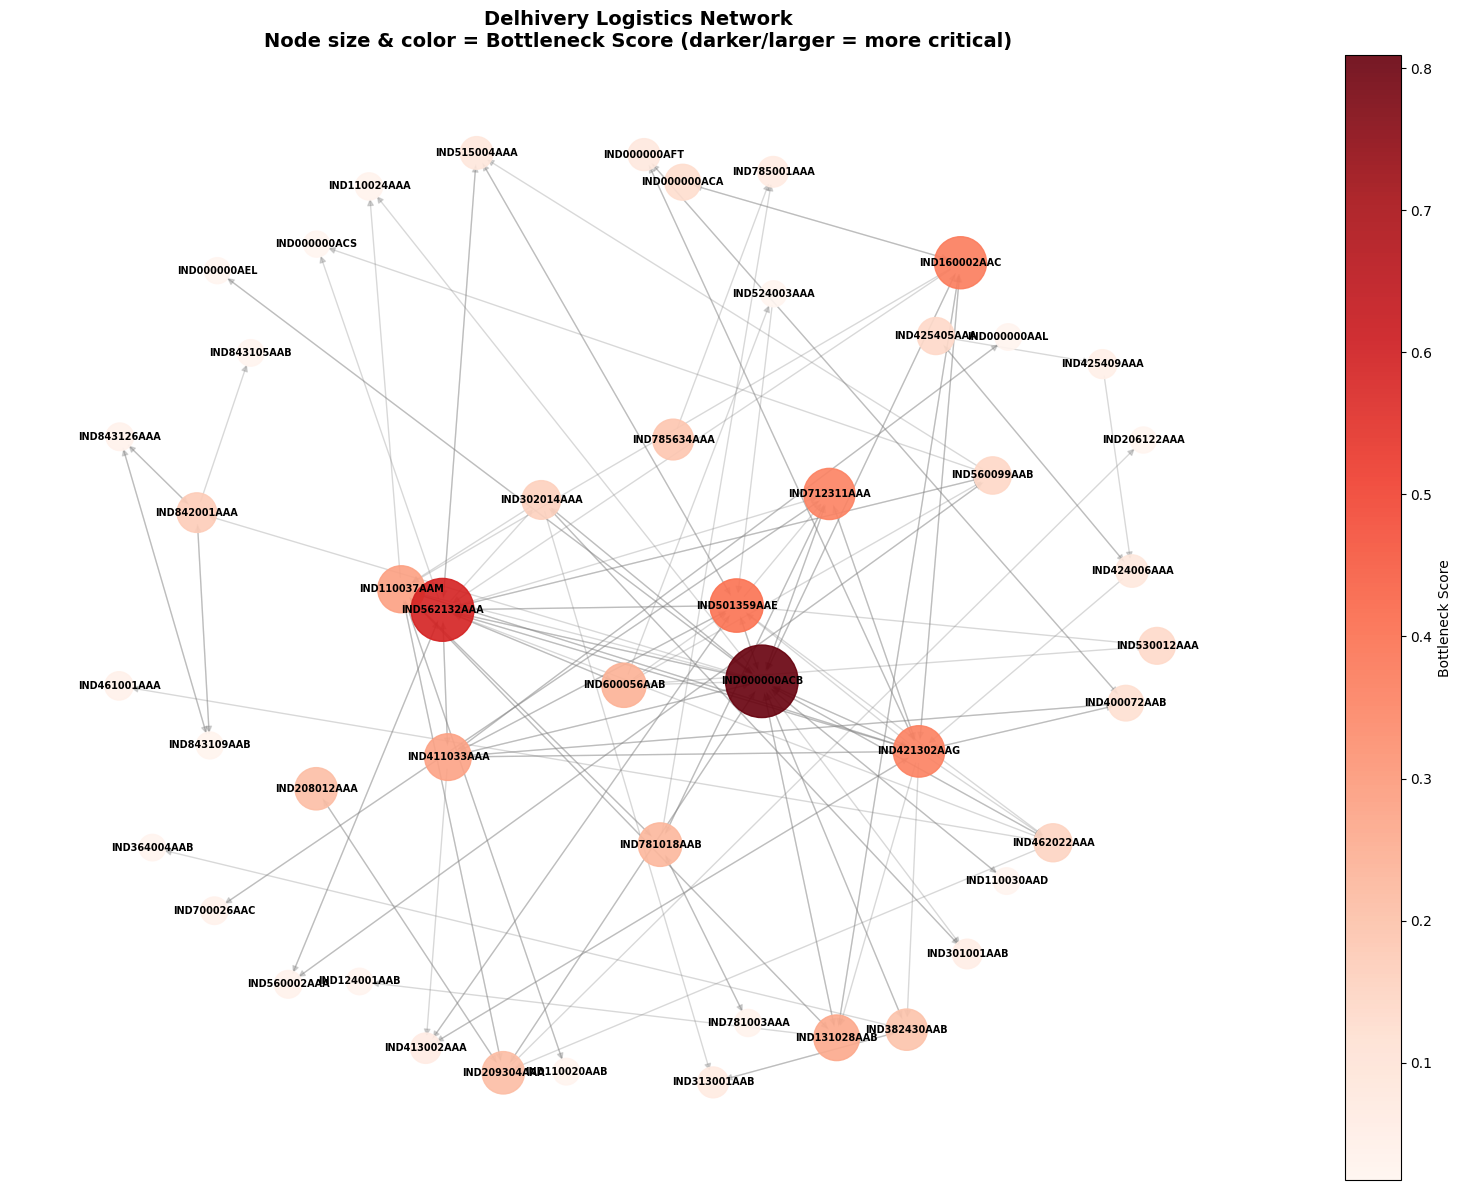

Network graph saved!


In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Load fresh if needed
G = nx.read_gexf('../data/logistics_graph.gexf')
hub_df = pd.read_csv('../data/hub_bottleneck_scores.csv')
hub_score_dict = dict(zip(hub_df['hub'], hub_df['bottleneck_score']))

# Only visualize top hubs and their connections (full graph is too large)
top_hubs = hub_df.head(20)['hub'].tolist()
subgraph_nodes = set(top_hubs)

# Add neighbors of top hubs
for hub in top_hubs:
    if hub in G:
        subgraph_nodes.update(list(G.neighbors(hub))[:3])

H = G.subgraph(subgraph_nodes)

# Node colors based on bottleneck score
node_colors = []
node_sizes = []
for node in H.nodes():
    score = hub_score_dict.get(node, 0)
    node_colors.append(score)
    node_sizes.append(300 + score * 3000)

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(H, seed=42, k=2)

nodes = nx.draw_networkx_nodes(H, pos, node_color=node_colors,
                                node_size=node_sizes,
                                cmap=plt.cm.Reds, alpha=0.9)
nx.draw_networkx_edges(H, pos, alpha=0.3, arrows=True,
                       arrowsize=10, edge_color='gray')
nx.draw_networkx_labels(H, pos, font_size=7, font_weight='bold')

plt.colorbar(nodes, label='Bottleneck Score')
plt.title('Delhivery Logistics Network\nNode size & color = Bottleneck Score (darker/larger = more critical)',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('../outputs/network_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Network graph saved!")